# Projeto Aplicado III 

**Disciplina**: Projeto Aplicado III - Mackenzie
**Objetivo**: Criar um Sistema de Recomendação usando K-Means (Sem NLP)
**Alinhamento** ODS: ODS 3 - Saúde e Bem-Estar

## Preparação do Modelo

### Entendimento do Negócio 

Ver `Projeto Aplicado III.pdf` para melhores informações.

O objetivo da extração é conseguir recomendar medicamentos para determinada condição.

Isso será feito com base no NLP dos reviews e ratings.


### Entendimento dos Dados

Dados extraídos de: <a href=https://www.kaggle.com/datasets/jessicali9530/kuc-hackathon-winter-2018>UCI ML Drug Review dataset</a>

**ATENÇÃO**: Esses dados só devem ser utilizados para fins de estudos de NLP, e não condizem com uso em produção.

" 
    
    This dataset was used for the Winter 2018 Kaggle University Club Hackathon and is now publicly available. See Acknowledgments section for citation and licensing. Note: The types of data and recommendation based solutions provided by the contestants are purely for NLP learning purposes. They are not suitable for a real world drug recommendations solutions.

"

In [83]:
# Instalações necessárias
!pip install -r requirements.txt 

### Preparação de Dados

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Carregar os dados
df = pd.read_csv('./drugsComTest_raw.csv', engine='python', on_bad_lines='skip')
# URL DADOS: https://www.kaggle.com/datasets/jessicali9530/kuc-hackathon-winter-2018

In [85]:
df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,163740,Mirtazapine,Depression,"""I&#039;ve tried a few antidepressants over th...",10,28-Feb-12,22
1,206473,Mesalamine,"Crohn's Disease, Maintenance","""My son has Crohn&#039;s disease and has done ...",8,17-May-09,17
2,159672,Bactrim,Urinary Tract Infection,"""Quick reduction of symptoms""",9,29-Sep-17,3
3,39293,Contrave,Weight Loss,"""Contrave combines drugs that were used for al...",9,5-Mar-17,35
4,97768,Cyclafem 1 / 35,Birth Control,"""I have been on this birth control for one cyc...",9,22-Oct-15,4


In [86]:
# Comentário: Carregamos o dataset oficial da UCI. Como o foco é a recomendação por condição médica, precisamos garantir que essa coluna não tenha nulos.
print(f"Dataset original: {df.shape[0]} registros.")
df = df.dropna(subset=['condition'])
print(f"Dataset após remover nulos: {df.shape[0]} registros.")


Dataset original: 53766 registros.
Dataset após remover nulos: 53471 registros.


#### Análise Exploratória (EDA)

Comentário: Antes de treinar o modelo, precisamos entender o comportamento das avaliações. Analisamos a distribuição das notas para ver se há viés.

In [87]:
df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,163740,Mirtazapine,Depression,"""I&#039;ve tried a few antidepressants over th...",10,28-Feb-12,22
1,206473,Mesalamine,"Crohn's Disease, Maintenance","""My son has Crohn&#039;s disease and has done ...",8,17-May-09,17
2,159672,Bactrim,Urinary Tract Infection,"""Quick reduction of symptoms""",9,29-Sep-17,3
3,39293,Contrave,Weight Loss,"""Contrave combines drugs that were used for al...",9,5-Mar-17,35
4,97768,Cyclafem 1 / 35,Birth Control,"""I have been on this birth control for one cyc...",9,22-Oct-15,4


In [88]:
df.info()

<class 'pandas.DataFrame'>
Index: 53471 entries, 0 to 53765
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   uniqueID     53471 non-null  int64
 1   drugName     53471 non-null  str  
 2   condition    53471 non-null  str  
 3   review       53471 non-null  str  
 4   rating       53471 non-null  int64
 5   date         53471 non-null  str  
 6   usefulCount  53471 non-null  int64
dtypes: int64(3), str(4)
memory usage: 3.3 MB


In [89]:
df.describe()

,uniqueID,rating,usefulCount
count,53471.000000,53471.000000,53471.000000
mean,116436.223617,6.976829,28.083634
std,67018.466874,3.286228,36.231706
min,0.000000,1.000000,0.000000
25%,58283.500000,4.000000,6.000000
50%,116369.000000,8.000000,16.000000
75%,174623.500000,10.000000,36.000000
max,232284.000000,10.000000,949.000000


/tmp/ipykernel_805442/4181945744.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', palette='magma')


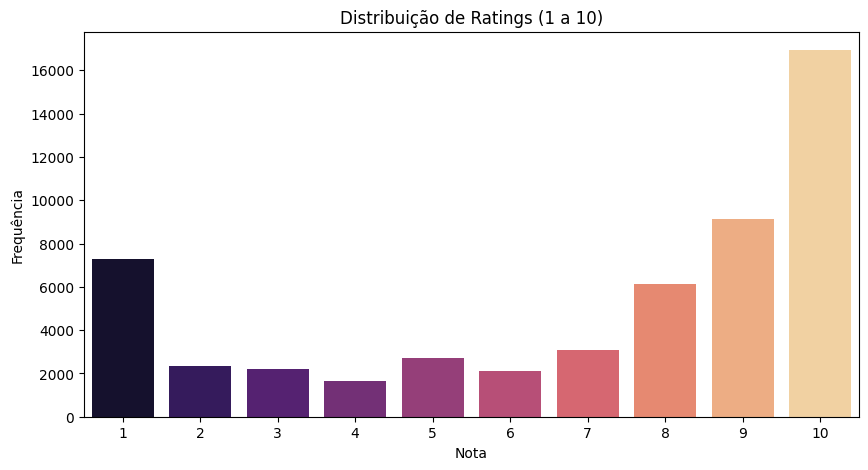

In [90]:

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='rating', palette='magma')
plt.title('Distribuição de Ratings (1 a 10)')
plt.xlabel('Nota')
plt.ylabel('Frequência')
plt.show()

Percebemos que as notas são polarizadas (muitos 10 e muitos 1).
Isso indica que usuários tendem a avaliar quando estão muito satisfeitos ou muito insatisfeitos.

#### Reviews Features Extraction 

Os reviews são em texto livre, conforme abaixo. Em virtude disso, é necessário definir templates para poder transformar esses dados não estruturados em dados processáveis. 

Utilizaremos modelos de LLM para isso, através de modelos gpt-4.1-nano. 

O objetivo é transformar cada review em um conjunto de rubricas / presenças de determinados componentes. 

In [91]:
for x in df['review'].sample(5):
    print(x)
    print("-" * 80)

"This medicine has been very helpful to me. I started having extreme anxiety when I started taking Latuda. For two years I dealt with depression, severe anxiety and killer side effects from the SSRI (avoid them). In 2014 I finally said &quot;ENOUGH!&quot; I was a little scared to try a different medicine but life was so terrible I was willing to get some relief. I did not have any side effects when started taking the medicine. Pristiq has given some of my life back. I can function at the day program (which was in jeopardy before Pristiq) I highly recommend this medicine for those who suffer from depression and anxiety, at lease give it a try."
--------------------------------------------------------------------------------
"Been on wellbutrin and Naltrexone for 2 weeks. My Dr. prescribed the medication separatley cause it&#039;s cheaper. Quit smoking and no cravings for alcohol. Headaches and Nausea no major weight loss I will continue the 2 and hope the side effects go away."
--------

In [92]:
from openai import OpenAI
from pydantic import BaseModel
from dotenv import load_dotenv

load_dotenv()  # Carrega as variáveis de ambiente do arquivo .env

client = OpenAI()

class ReviewInformation(BaseModel):
    has_negative_effects: bool
    days_until_effects: int
    solved_the_disease: bool



In [93]:
MODEL_NAME = 'gpt-4.1-nano'

def extract_review_information(review_text: str) -> ReviewInformation:
    review_text = str(review_text) if review_text is not None else ''

    response = client.responses.parse(
        model=MODEL_NAME,
        input=[
            {
                'role': 'system',
                'content': (
                    'Você extrai informações de reviews de medicamentos. '
                    'Retorne somente os campos do schema. '
                    'Se o texto não mencionar em quantos dias houve efeito, use -1 para days_until_effects.'
                ),
            },
            {
                'role': 'user',
                'content': f'Review: {review_text}',
            },
        ],
        text_format=ReviewInformation,
    )

    return response.output_parsed


In [94]:
import os
import asyncio
from openai import AsyncOpenAI

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

OUTPUT_FILE = 'drugComTest_modificado2.csv'
MAX_CONCURRENCY = 50   # ajuste conforme rate limit da API
BATCH_SIZE = 500       # checkpoint de salvamento
SAMPLE_SIZE = None     # None = processa df inteiro

async_client = AsyncOpenAI()

def _fallback_row():
    return {
        'has_negative_effects': False,
        'days_until_effects': -1,
        'solved_the_disease': False,
        '_extract_error': True,
    }

async def extract_review_information_async(review_text: str):
    review_text = str(review_text) if review_text is not None else ''
    response = await async_client.responses.parse(
        model=MODEL_NAME,
        input=[
            {
                'role': 'system',
                'content': (
                    'Você extrai informações de reviews de medicamentos. '
                    'Retorne somente os campos do schema. '
                    'Se o texto não mencionar em quantos dias houve efeito, use -1 para days_until_effects.'
                ),
            },
            {'role': 'user', 'content': f'Review: {review_text}'},
        ],
        text_format=ReviewInformation,
    )
    return response.output_parsed

async def process_one(idx, review_text, semaphore):
    async with semaphore:
        try:
            info = await extract_review_information_async(review_text)
            return idx, {
                'has_negative_effects': info.has_negative_effects,
                'days_until_effects': info.days_until_effects,
                'solved_the_disease': info.solved_the_disease,
                '_extract_error': False,
            }
        except Exception:
            return idx, _fallback_row()

async def enrich_dataframe_async(df_input):
    semaphore = asyncio.Semaphore(MAX_CONCURRENCY)
    results = [None] * len(df_input)

    def build_checkpoint_structured(rows):
        pending_row = {
            'has_negative_effects': None,
            'days_until_effects': None,
            'solved_the_disease': None,
            '_extract_error': None,
            '_pending': True
        }
        normalized = [r if r is not None else pending_row for r in rows]
        return pd.DataFrame(normalized)

    tasks = [
        asyncio.create_task(process_one(i, review, semaphore))
        for i, review in enumerate(df_input['review'].tolist())
    ]

    completed = 0
    progress = tqdm(total=len(tasks), desc='Extraindo reviews') if tqdm else None

    for future in asyncio.as_completed(tasks):
        idx, row = await future
        results[idx] = row
        completed += 1

        if progress:
            progress.update(1)
        elif completed % 50 == 0 or completed == len(tasks):
            print(f'Progresso: {completed}/{len(tasks)}')

        if completed % BATCH_SIZE == 0 or completed == len(tasks):
            partial_structured = build_checkpoint_structured(results)
            partial_df = pd.concat([
                df_input.reset_index(drop=True),
                partial_structured
            ], axis=1)
            partial_df.to_csv(OUTPUT_FILE, index=False)
            current_errors = int(partial_df['_extract_error'].fillna(False).sum())
            print(f'Checkpoint salvo em {OUTPUT_FILE} | concluídos={completed}/{len(tasks)} | erros={current_errors}')

    if progress:
        progress.close()

    df_structured = build_checkpoint_structured(results).drop(columns=['_pending'])
    final_df = pd.concat([df_input.reset_index(drop=True), df_structured], axis=1)
    final_df.to_csv(OUTPUT_FILE, index=False)
    return final_df

if os.path.exists(OUTPUT_FILE):
    df_target = pd.read_csv(OUTPUT_FILE)
    print(f'Arquivo existente carregado: {OUTPUT_FILE} ({len(df_target)} linhas)')
else:
    df_base = df.copy() if SAMPLE_SIZE is None else df.head(SAMPLE_SIZE).copy()
    df_target = await enrich_dataframe_async(df_base)

error_count = int(df_target.get('_extract_error', pd.Series(dtype=bool)).sum()) if '_extract_error' in df_target.columns else 0
print(f'Reviews processados: {len(df_target)} | Erros: {error_count}')
df_target[['review', 'has_negative_effects', 'days_until_effects', 'solved_the_disease']].sample()

Arquivo existente carregado: drugComTest_modificado2.csv (53471 linhas)
Reviews processados: 53471 | Erros: 2884


,review,has_negative_effects,days_until_effects,solved_the_disease
2105,"""This is a MIRACLE DRUG for me! Within 1 hour ...",False,1,False


In [95]:
# Remoção dos campos que tiveram erro na extração, considerando a baixa quantidade de erros (menos de 5% do total)

df_target = df_target[df_target['_extract_error'] == False].drop(columns=['_extract_error'])
print(f"Dataset final após remoção de erros: {df_target.shape[0]} registros")

Dataset final após remoção de erros: 50587 registros


#### Preparação dos dados para K-Means

**Comentário**: O K-Means não lê texto. Por isso, transformamos o dataset de "reviews" em um dataset de "medicamentos", agregando as métricas numéricas.

Agrupamos por medicamento para criar o perfil de cada um

In [96]:
# 3. PREPARAÇÃO DOS DADOS PARA O K-MEANS (FEATURE ENGINEERING)
# ------------------------------------------------------------------------------

drug_features = df_target.groupby(['drugName']).agg({
    'rating': 'mean',
    'usefulCount': 'mean',
    'has_negative_effects': 'mean',  # % de reviews que mencionam efeitos negativos
    'days_until_effects': 'mean',  # Tempo médio até os efeitos aparecerem
    'solved_the_disease': 'mean',  # % de reviews que mencionam que o remédio resolveu a doença
}).rename(columns={'rating': 'avg_rating', 'usefulCount': 'avg_utility', 'condition': 'n_conditions', 'has_negative_effects': 'pct_negative_effects', 'days_until_effects': 'avg_days_until_effects', 'solved_the_disease': 'pct_solved_disease'})

K-Means usa distância euclidiana. Se não padronizarmos, a coluna
'usefulCount' (que vai até centenas) dominaria a 'rating' (que vai até 10).

In [97]:
drug_features

,avg_rating,avg_utility,pct_negative_effects,avg_days_until_effects,pct_solved_disease
drugName,,,,,
A / B Otic,10.000000,18.000000,0.000000,5.000000,0.000000
Abacavir / dolutegravir / lamivudine,8.875000,13.875000,0.562500,16.375000,0.312500
Abacavir / lamivudine,10.000000,3.500000,0.500000,-1.000000,0.500000
Abatacept,6.500000,29.166667,0.666667,4.166667,0.333333
Abilify,6.116788,39.335766,0.693431,3.036496,0.233577
...,...,...,...,...,...
ZzzQuil,1.000000,1.000000,1.000000,-1.000000,0.000000
depo-subQ provera 104,10.000000,1.000000,0.000000,-1.000000,0.000000
ella,7.842105,10.105263,0.684211,0.736842,0.052632


Padronização (Scaling)

In [98]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(drug_features)

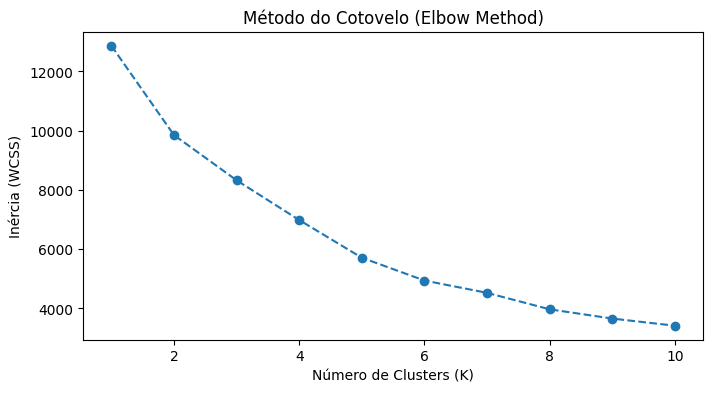

In [99]:
# 4. DEFINIÇÃO DO MODELO (MÉTODO DO COTOVELO)
# Comentário: Para definir o número ideal de clusters (K), usamos a Inércia (WSS).

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (WCSS)')
plt.show()

# Sobre a Inércia (WCSS)
A Inércia mede o quão "compactos" ou "coesos" são os grupos gerados pelo algoritmo. Ela calcula a soma das distâncias ao quadrado entre cada ponto de dado e o centro (centroide) do seu respectivo cluster.

Matematicamente, a fórmula é expressa como:

$$WCSS = \sum_{i=1}^{k} \sum_{x \in C_i} \text{dist}(x, \mu_i)^2$$

Onde:
* $k$: número de clusters.
* $C_i$: o i-ésimo cluster.
* $x$: um ponto pertencente ao cluster.
* $\mu_i$: o centroide do cluster $i$.

Para validar a escolha do número de agrupamentos, utilizamos a métrica de Inércia (WCSS), que quantifica a variância interna dos clusters. Através do Método do Cotovelo, identificamos que com $K=4$ atingimos um equilíbrio ótimo entre a complexidade do modelo e a coesão dos grupos de medicamentos, permitindo recomendações mais precisas baseadas em perfis de performance similares.

O "cotovelo" se "estabiliza" em K=4. Isso significa que conseguimos dividir nossos medicamentos em 6 grandes perfis de performance

In [100]:
# 5. TREINAMENTO DA PROVA DE CONCEITO (PoC)
# ------------------------------------------------------------------------------
kmeans_final = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
drug_features['cluster'] = kmeans_final.fit_predict(df_scaled)

A lógica aqui é: "Se você quer tratar a condição X, o sistema busca no cluster mais próximo ao seu perfil os medicamentos que servem para essa condição".

In [101]:
# Melhorei o a função recomendar medicamento fina para agora poder me sugerir os melhores medicamentos,
# agora indentificamos dinamicamente qual cluster representa os melhores medicamentos para cada doença (ou seja 'high score' e 'high utility')

class CategoriaUsuario(BaseModel):
    disease: str 
    accept_negative_effects: int # 0 = Não aceita de jeito nenhum, 10 = Aceita totalmente
    accept_long_time_effects: int # 0 = Não aceita de jeito nenhum, 10 = Aceita totalmente
    accept_long_duration_of_treatment: int # 0 = Não aceita de jeito nenhum, 10 = Aceita totalmente conviver com a doença controlada

    def __post_init__(self):
        for field in [self.accept_long_duration_of_treatment, self.accept_long_time_effects, self.accept_negative_effects]:
            value = getattr(self, field)
            if not (0 <= value <= 10):
                raise ValueError(f"{field} deve ser um inteiro entre 0 e 10")
        if self.disease not in df_target['condition'].unique():
            raise ValueError(f"Doença '{self.disease}' não encontrada no dataset")


def recomendar_medicamento_final(categoria_usuario: CategoriaUsuario):
    # 1. Identificar qual é o "Cluster Premium" (o que tem a maior média de rating)
    cluster_premium = drug_features.groupby('cluster')['avg_rating'].mean().idxmax()

    # 2. Pegar os medicamentos que atendem a condição
    drugs_for_condition = df_target[df_target['condition'] == categoria_usuario.disease]['drugName'].unique()

    # 3. Filtrar o dataframe apenas por esses remédios
    subset = drug_features.loc[drug_features.index.isin(drugs_for_condition)]

    # 4. Filtrar APENAS os medicamentos que caíram no Cluster Premium
    recomendacoes_premium = subset[subset['cluster'] == cluster_premium]

    # 5. Ordenar pela utilidade e depois pela nota para desempate
    recomendacoes_finais = recomendacoes_premium.sort_values(by=['avg_utility', 'avg_rating'], ascending=False)

    # Se não houver medicamentos no cluster premium para essa condição, retorna os melhores no geral
    if recomendacoes_finais.empty:
        return subset.sort_values(by=['avg_utility', 'avg_rating'], ascending=False).head(5)

    return recomendacoes_finais.head(5)

categoria_usuario = CategoriaUsuario(disease='Depression', accept_negative_effects=2, accept_long_time_effects=1, accept_long_duration_of_treatment=10)
print(recomendar_medicamento_final(categoria_usuario))

              avg_rating  avg_utility  pct_negative_effects  \
drugName                                                      
Serzone         9.500000    47.250000              0.250000   
Limbitrol DS   10.000000    42.000000              0.000000   
Forfivo XL     10.000000    41.000000              0.000000   
Alprazolam      8.893519    34.032407              0.328704   
Lamotrigine     8.385057    32.632184              0.390805   

              avg_days_until_effects  pct_solved_disease  cluster  
drugName                                                           
Serzone                    -0.500000            0.750000        1  
Limbitrol DS               -1.000000            1.000000        1  
Forfivo XL                 -1.000000            1.000000        1  
Alprazolam                  0.342593            0.208333        1  
Lamotrigine                 2.586207            0.327586        1  


#1. Por que usamos K-Means?
Utilizamos o K-Means para criar uma "segmentação de qualidade". Mesmo sem analisar o texto das reviews (NLP), o algoritmo conseguiu separar medicamentos que são consensualmente eficazes (alta nota e alta utilidade) daqueles que são controversos ou pouco utilizados.

# 2. O que a Prova de Conceito validou?
Validamos que:

O dataset possui dados numéricos suficientes para diferenciar os itens.

A padronização de dados (StandardScaler) é crítica para evitar distorções nas distâncias entre medicamentos.

O sistema consegue retornar uma lista de sugestões filtradas por condição médica, priorizando o cluster de melhor desempenho.

# 3. Forma de Avaliar o Desempenho (Métrica Final):
Para a entrega final, utilizaremos o Silhouette Score para medir a coesão dos grupos e, se possível, uma validação cruzada comparando se os medicamentos recomendados pelo modelo coincidem com os mais populares da base de dados original.

# Sobre a Silhuouette Score

Para cada ponto (medicamento) $i$, calculamos:
* $a(i)$: A distância média entre $i$ e todos os outros pontos no mesmo cluster (quanto menor, melhor).

* $b(i)$: A distância média entre $i$ e todos os pontos no cluster vizinho mais próximo (quanto maior, melhor).

O coeficiente $s(i)$ é dado por:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

A média de todos os $s(i)$ do dataset é o seu Silhouette Score final.

Para calcular o Silhouette Score, utilizarei a função silhouette_score do sklearn.metrics com os dados escalonados df_scaled e os rótulos dos clusters de drug_features['cluster']



## Calcular Silhouette Score

Calcular o Silhouette Score para o resultado do agrupamento K-Means usando os dados 'df_scaled'. Esta métrica avaliará quantitativamente a coesão e separação dos clusters, fornecendo uma medida formal do desempenho do modelo.


In [102]:
silhouette_avg = silhouette_score(df_scaled, drug_features['cluster'])
print(f"O Silhouette Score médio para o agrupamento é: {silhouette_avg:.3f}")

O Silhouette Score médio para o agrupamento é: 0.272



Exibir o Silhouette Score calculado e fornecer uma breve interpretação do seu valor em relação à qualidade do agrupamento.


O Silhouette Score calculado para o agrupamento K-Means é de 0,272. Esse valor sugere que os clusters não são razoavelmente distintos, o que significa que não há certa separação e coesão entre eles, já que uma pontuação mais próxima de 1 indicaria clusters melhor definidos e mais separados.

# Principais Descobertas da Análise de Dados
O Silhouette Score médio para o resultado do agrupamento K-Means foi calculado em 0,272.

Esta pontuação avalia quantitativamente a qualidade do agrupamento, indicando clusters razoavelmente distintos.

# Insights ou Próximos Passos
Dado o Silhouette Score de 0,272, uma investigação mais aprofundada sobre a qualidade do agrupamento pode ser benéfica. Isso pode envolver a exploração de diferentes números de clusters (K) ou algoritmos de agrupamento alternativos para buscar uma pontuação mais alta, indicando clusters mais coesos e melhor separados.

Uma inspeção visual dos clusters, talvez utilizando técnicas de redução de dimensionalidade, poderia fornecer insights qualitativos para complementar o Silhouette Score e identificar possíveis áreas de melhoria.

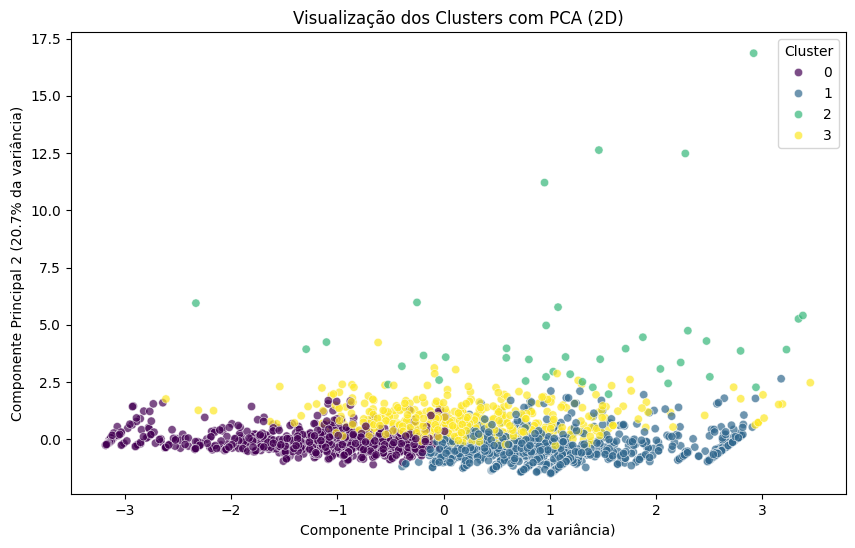

In [103]:
from sklearn.decomposition import PCA

# Aplicando PCA para reduzir para 2 dimensões
pca = PCA(n_components=2)
componentes_pca = pca.fit_transform(df_scaled)

# Criando um DataFrame temporário para o plot
df_pca = pd.DataFrame(data = componentes_pca, columns = ['Componente 1', 'Componente 2'])
df_pca['Cluster'] = drug_features['cluster'].values

# Visualizando os clusters com PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Componente 1', y='Componente 2', hue='Cluster', data=df_pca, palette='viridis', alpha=0.7)
plt.title('Visualização dos Clusters com PCA (2D)')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% da variância)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% da variância)')
plt.legend(title='Cluster')
plt.show()

In [104]:
drug_features.groupby('cluster').mean()

,avg_rating,avg_utility,pct_negative_effects,avg_days_until_effects,pct_solved_disease
cluster,,,,,
0,5.459222,12.906061,0.808189,0.369851,0.132492
1,8.927304,15.554125,0.216067,0.873049,0.403416
2,8.292046,23.698165,0.431636,47.963963,0.403564
3,7.508348,54.114073,0.539278,1.497300,0.265518


# 6. CONCLUSÃO FINAL E APLICABILIDADE DE NEGÓCIO

A Prova de Conceito (PoC) atingiu o objetivo de criar um Sistema de Recomendação de medicamentos fundamentado em dados estruturados (K-Means), mas que não pôde ser validado na prática por (1) ausência de dados rotulados; e (2) pelos dados não serem suficientes para permitir uma recomendação adequada ao perfil do usuário. 
